# stock price prediction

# importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Manupulation

In [ ]:
#load dataset
tesla = pd.read_csv("dataset/tesla.csv")
tesla

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2188,11-03-2019,283.519989,291.279999,280.500000,290.920013,290.920013,7392300
2189,12-03-2019,286.489990,288.070007,281.059998,283.359985,283.359985,7504100
2190,13-03-2019,283.899994,291.989990,282.700012,288.959991,288.959991,6844700
2191,14-03-2019,292.450012,295.390015,288.290009,289.959991,289.959991,7074200


In [3]:
tesla['Date']= pd.to_datetime(tesla['Date'])

C:\Users\arnab\AppData\Local\Temp\ipykernel_22660\22334479.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  tesla['Date']= pd.to_datetime(tesla['Date'])


In [4]:
print(f'Dataframe contains data from date {tesla.Date.min()} to {tesla.Date.max()}')
print(f'Total no of days = {(tesla.Date.max() - tesla.Date.min()).days} days')

Dataframe contains data from date 2010-06-29 00:00:00 to 2019-03-15 00:00:00
Total no of days = 3181 days


In [5]:
#information of tesla dataframe
tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2193 non-null   datetime64[ns]
 1   Open       2193 non-null   float64       
 2   High       2193 non-null   float64       
 3   Low        2193 non-null   float64       
 4   Close      2193 non-null   float64       
 5   Adj Close  2193 non-null   float64       
 6   Volume     2193 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 120.1 KB


In [6]:
#description of data
tesla.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,2193,2193.000000,2193.000000,2193.000000,2193.000000,2193.000000,2.193000e+03
mean,2014-11-04 14:37:15.841313024,175.652882,178.710262,172.412075,175.648555,175.648555,5.077449e+06
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,2012-08-29 00:00:00,33.110001,33.910000,32.459999,33.160000,33.160000,1.577800e+06
50%,2014-11-04 00:00:00,204.990005,208.160004,201.669998,204.990005,204.990005,4.171700e+06
75%,2017-01-09 00:00:00,262.000000,265.329987,256.209991,261.739990,261.739990,6.885600e+06
max,2019-03-15 00:00:00,386.690002,389.609985,379.350006,385.000000,385.000000,3.716390e+07
std,NaN,115.580903,117.370092,113.654794,115.580771,115.580771,4.545398e+06


In [7]:
tesla.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Data Visualization

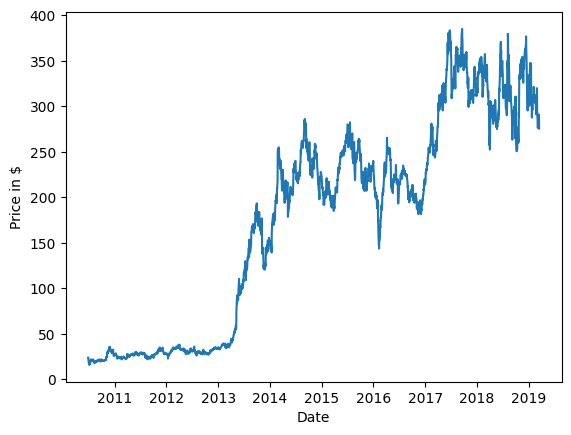

In [8]:
sns.lineplot(x="Date",y="Close",data=tesla)
plt.ylabel("Price in $")
plt.show()

# splitting data into train test split

In [9]:
#input Variable. (here we work with 2000 rows of data to train & test model, and rest 193 will be used for testing)
x=tesla[['Open','High','Low','Volume']].head(2000)
x

,Open,High,Low,Volume
0,19.000000,25.000000,17.540001,18766300
1,25.790001,30.420000,23.299999,17187100
2,25.000000,25.920000,20.270000,8218800
3,23.000000,23.100000,18.709999,5139800
4,20.000000,20.000000,15.830000,6866900
...,...,...,...,...
1995,285.859985,291.950012,283.839996,5424400
1996,294.339996,299.000000,293.549988,4797800
1997,297.700012,297.799988,286.739990,5995200
1998,300.500000,322.170013,297.480011,18767300


In [10]:
# output variable
y=tesla['Close'].head(2000)
y

0        23.889999
1        23.830000
2        21.959999
3        19.200001
4        16.110001
           ...    
1995    291.820007
1996    296.739990
1997    291.130005
1998    319.500000
1999    316.089996
Name: Close, Length: 2000, dtype: float64

In [11]:
#split dataset into train & test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.20, random_state= 51)

In [12]:
x_train

,Open,High,Low,Volume
1316,263.980011,271.570007,255.800003,6120200
383,28.209999,28.670000,27.500000,630100
873,148.479996,150.429993,146.100006,6675300
418,34.230000,34.520000,33.270000,959900
1811,345.980011,352.480011,343.450012,4239200
...,...,...,...,...
1993,283.290009,295.010010,281.600006,7489700
1760,386.690002,386.950012,373.100006,6604100
485,30.070000,30.290001,28.750000,1118700
57,20.670000,21.350000,20.160000,947500


In [13]:
x_test

,Open,High,Low,Volume
1617,195.559998,196.729996,189.500000,4439300
885,150.000000,152.190002,148.600006,4695000
433,34.900002,35.889999,34.830002,729300
188,22.700001,23.540001,22.549999,1058100
1264,259.320007,260.799988,254.309998,6221100
...,...,...,...,...
1893,312.869995,318.549988,305.679993,9946300
800,173.399994,173.699997,166.399994,12061100
1426,192.399994,196.350006,189.220001,4499000
1621,182.509995,188.889999,182.509995,4072200


In [14]:
y_train

1316    264.200012
383      27.709999
873     147.940002
418      33.750000
1811    350.609985
           ...    
1993    291.720001
1760    377.489990
485      29.500000
57       21.059999
1022    219.580002
Name: Close, Length: 1600, dtype: float64

In [15]:
y_test

1617    189.570007
885     149.559998
433      35.320000
188      23.250000
1264    254.960007
           ...    
1893    314.619995
800     168.940002
1426    191.929993
1621    186.800003
1973    299.920013
Name: Close, Length: 400, dtype: float64

# Feature Scalling

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

# Machine Learning Model Building

For model evaluation

In [17]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score
models= dict()   

# Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

In [19]:
print(f'r2 score: {r2_score(y_test, y_pred_lr)}')
print(f'MSE score: {mse(y_test, y_pred_lr)}') 
models["Linear Regression"] = str(r2_score(y_test, y_pred_lr))

r2 score: 0.9997655325374357
MSE score: 2.9031877476711303


# Decision Tree Regressor

In [20]:
from sklearn.tree import DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(criterion='squared_error',random_state = 51)
dt_regressor.fit(x_train, y_train)
y_pred_dtr = dt_regressor.predict(x_test)

In [21]:
print(f'r2 score: {r2_score(y_test, y_pred_dtr)}')
print(f'MSE score: {mse(y_test,y_pred_dtr)}')  
models["Decission Tree"] = str(r2_score(y_test, y_pred_dtr))

r2 score: 0.9990981863707347
MSE score: 11.166301074496692


# Random Forest Regressor

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100,criterion='squared_error',random_state = 51)
rf_regressor.fit(x_train, y_train)
y_pred_rfr = rf_regressor.predict(x_test)

In [23]:
print(f'r2 score: {r2_score(y_test, y_pred_rfr)}')
print(f'MSE score: {mse(y_test,y_pred_rfr)}')  
models["Random Forest"] = str(r2_score(y_test, y_pred_rfr))

r2 score: 0.9995688248973538
MSE score: 5.33883150102421


# Support Vector Machine

In [24]:
# Support vector Regressor
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train, y_train)
y_pred_svr = svr.predict(x_test)

In [25]:
print(f'r2 score: {r2_score(y_test, y_pred_svr)}')
print(f'MSE score: {mse(y_test,y_pred_svr)}')  
models["SVR"] = str(r2_score(y_test, y_pred_svr))

r2 score: 0.5652371673252181
MSE score: 5383.254952137426


In [26]:
# Train with standard scaled data
svr2 = SVR()
svr2.fit(x_train_sc, y_train)
y_pred_svr_sc = svr2.predict(x_test_sc)

In [27]:
print(f'r2 score: {r2_score(y_test, y_pred_svr_sc)}')
print(f'MSE score: {mse(y_test,y_pred_svr_sc)}')  
models["SVR_sc"] = str(r2_score(y_test, y_pred_svr_sc))

r2 score: 0.9852434824327959
MSE score: 182.71593222729933


# Best Model

<BarContainer object of 5 artists>

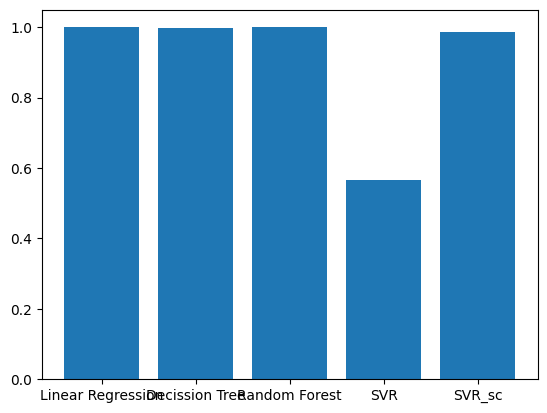

In [28]:
model_names = list(models.keys())
accuracy = list(map(float, models.values()))
# creating the bar plot
plt.bar(model_names, accuracy)

In [29]:
models

{'Linear Regression': '0.9997655325374357',
 'Decission Tree': '0.9990981863707347',
 'Random Forest': '0.9995688248973538',
 'SVR': '0.5652371673252181',
 'SVR_sc': '0.9852434824327959'}

From above, we can see that Linear Regression performed the best, closely followed by Random Forest Regressor, Decission Tree. So we will be choosing Linear Regression for the final model.

# Testing

In [30]:
x_test.tail(193)

,Open,High,Low,Volume
39,19.250000,19.709999,18.950001,673100
559,30.000000,30.650000,29.650000,1536600
405,31.100000,31.900000,31.049999,652100
175,24.660000,24.990000,24.270000,924800
1300,231.000000,244.750000,230.809998,7656000
...,...,...,...,...
1893,312.869995,318.549988,305.679993,9946300
800,173.399994,173.699997,166.399994,12061100
1426,192.399994,196.350006,189.220001,4499000
1621,182.509995,188.889999,182.509995,4072200


In [31]:
#predicted closing value
pred=lr.predict(x.tail(193))

In [32]:
#dataframe showing actual vs predicted closing values
predicted=pd.DataFrame({"actual close":y.tail(193),"predicted close":pred}) 
predicted

,actual close,predicted close
1807,355.899994,356.936658
1808,355.399994,355.269035
1809,349.589996,348.921863
1810,344.529999,344.416821
1811,350.609985,349.373974
...,...,...
1995,291.820007,289.311723
1996,296.739990,297.508049
1997,291.130005,289.113641
1998,319.500000,316.400969


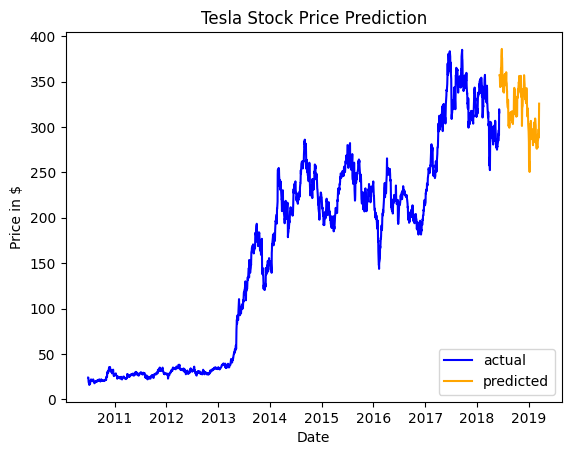

In [33]:
#plotting predicted data along with actual price visually
date= tesla['Date'].head(2000)
close= tesla['Close'].head(2000)
date2= tesla['Date'].tail(193)
plt.plot(date,close, color='b', label="actual")
plt.plot(date2,pred, color='orange', label="predicted")                
plt.title("Tesla Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price in $")
plt.legend(loc=4)
plt.show()

# Export model

In [34]:
import joblib
joblib.dump(lr, "stock_price_ml_model.pkl")

['stock_price_ml_model.pkl']